In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import sounddevice as sd
from scipy.interpolate import interp1d

Spatial aliasing limit: 3430.0 Hz
Array HPBW: 29.02 deg
87.06036401233347


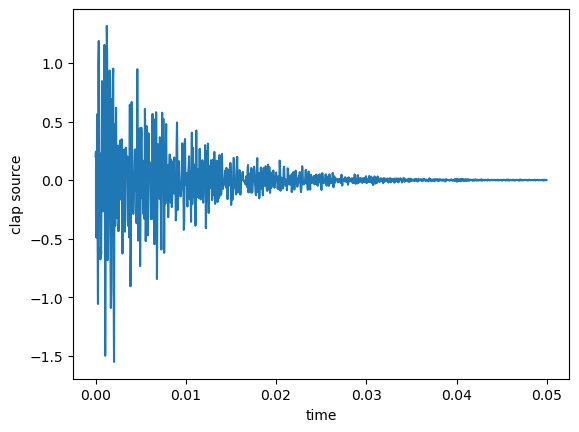

In [2]:
# Speed of sound (m/s) and random seed for reproducibility
c = 343.0
np.random.seed(0)

# Array and signal parameters
fs = 22500
T = 0.05
N = int(fs * T)   
t = np.arange(0, T, 1/fs)

M = 4                    # Number of microphones in linear array
d = 0.05                # Spacing between microphones (m), 2 cm ~ 8.6 kHz aliasing limit

def hpbw_deg(f_hz, d=d, M=M): 
    '''Calculate the half-power beamwidth in degrees for uniform linear array at representative frequency f_hz'''
    l = c / f_hz
    return np.rad2deg(0.886 * (l / (M * d)))

def spatial_aliasing_limit(d):
    '''Calculate the spatial aliasing limit frequency for a given microphone spacing d'''
    return c / (2 * d)

print(f"Spatial aliasing limit: {spatial_aliasing_limit(d):.1f} Hz")
print (f"Array HPBW: {hpbw_deg(np.floor(spatial_aliasing_limit(d)/1000) * 1000):.2f} deg")

print(hpbw_deg(1000))
# Define array geometry (along x-axis, centered at 0)
mic_positions = np.arange(M) * d
mic_positions = mic_positions - np.mean(mic_positions)

# Source
noise = np.random.randn(len(t))
decay_time = 0.008    # 8 ms decay (typical clap)
envelope = np.exp(-t / decay_time)

def bandpass (x, fs, f_lo, f_hi, order=4): 
    b, a = signal.butter(order, [f_lo/(fs/2), f_hi/(fs/2)], btype='band')
    return signal.lfilter(b, a, x)

s = envelope * noise


s = bandpass(s, fs, 2000, 8000)

plt.figure()
plt.plot(t, s)
plt.xlabel('time')
plt.ylabel('clap source')
plt.show()
sd.play(s, fs)



C:\Users\bryan\AppData\Local\Temp\ipykernel_13744\3302657511.py:21: RuntimeWarning: divide by zero encountered in divide
  return c / (2 * d)
C:\Users\bryan\AppData\Local\Temp\ipykernel_13744\3302657511.py:17: RuntimeWarning: divide by zero encountered in divide
  return np.rad2deg(0.886 * (l / (M * d)))


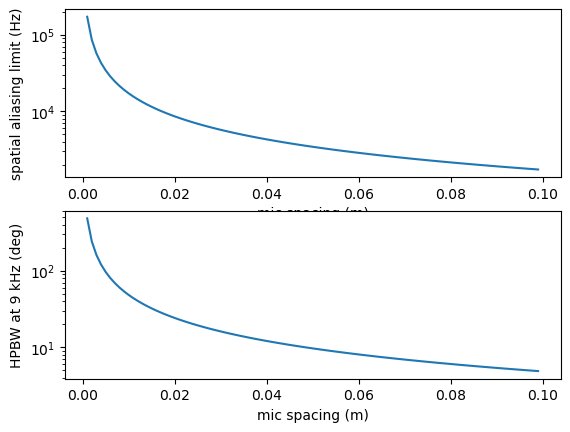

In [3]:
d_ = np.arange(100) * 0.001
plt.figure()
plt.subplot(2,1,1)
plt.plot(d_, spatial_aliasing_limit(d_))
plt.xlabel('mic spacing (m)')
plt.ylabel('spatial aliasing limit (Hz)')
plt.yscale('log')
plt.subplot(2,1,2)
plt.plot(d_, hpbw_deg(9000, d_))
plt.xlabel('mic spacing (m)')
plt.ylabel('HPBW at 9 kHz (deg)')
plt.yscale('log')

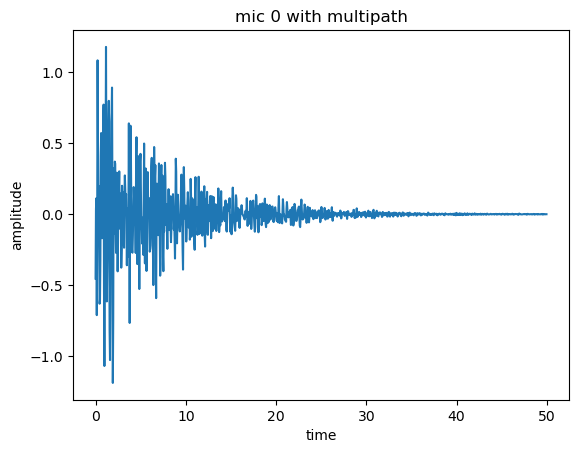

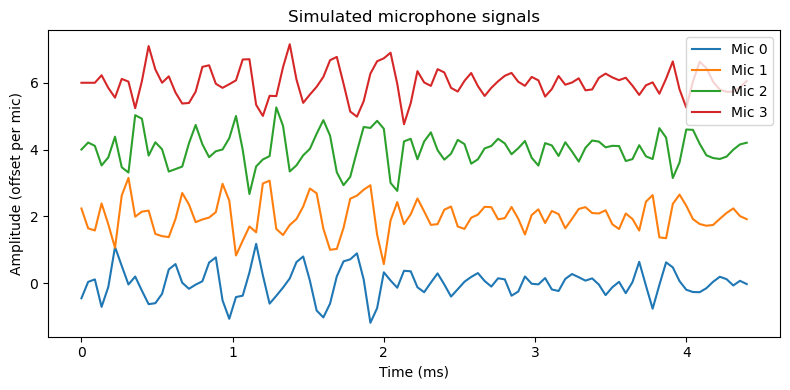

In [4]:
theta_deg = 30        # True DOA of the source (degrees, 0 = broadside, positive = from +y)

# Multipath environment modeling
paths = [
    # (angle_deg, delay_ms, attenuation)
    (theta_deg, 0.0, 1.00), # direct path
    # (-20, 1, 0.8),
    # (40, 3.0, 0.50), 
    # (-40, 3.1, 0.40), 
    # (-70, 6.5, 0.30), 
    # (-30, 12.0, 0.15),
]
# Generate received signals at each microphone using geometric delays
X = np.zeros((M, N))

# Assume far-field source in the x-y plane; array along x-axis.

for angle_deg, delay_ms, attn in paths: 
    theta = np.deg2rad(angle_deg)
    delay = delay_ms / 1000.0

    for m in range(M):
        # Geometric delay for microphone m
        tau_geom = mic_positions[m] * np.sin(theta) / c
        tau_total = tau_geom + delay

        interp = interp1d(t, s, bounds_error=False, fill_value=0)
        # noise = 0.05 * np.random.randn(N)
        noise = 0

        X[m, :] += attn * interp(t - tau_total) + noise

plt.figure()
plt.plot(t * 1e3, X[0])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('mic 0 with multipath')
plt.show()

# Plot example microphone signals
plt.figure(figsize=(8, 4))
for m in range(M):
    plt.plot(t[:100] * 1e3, X[m][:100] + m * 2, label=f"Mic {m}")  # offset for visualization
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (offset per mic)")
plt.title("Simulated microphone signals")
plt.tight_layout()
plt.legend()
plt.show()

Estimated DOA: 37.00 deg (True DOA: 30 deg)


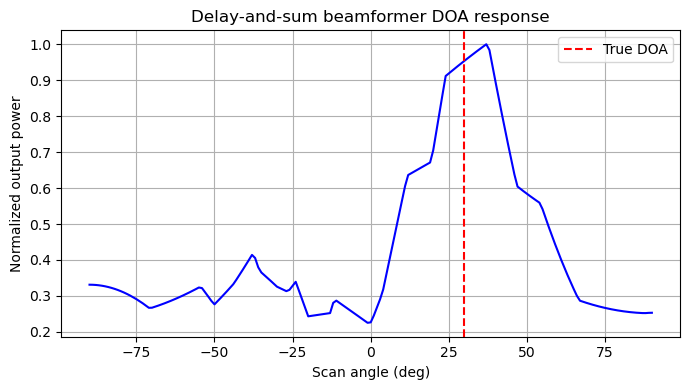

In [6]:
# Delay-and-sum beamformer DOA scan

def detect_first_arrival(X, threshold=0.2):
    """
    Detect the first significant arrival across the array.

    Parameters
    ----------
    X : ndarray, shape (M, N)
        Multichannel signal (microphones x time).
    threshold : float
        Energy threshold as a fraction of the maximum envelope energy.

    Returns
    -------
    idx_peak : int
        Sample index of the first detected arrival (based on array-averaged envelope).
    """
    # Average across microphones to get an array-wide signal
    x_avg = np.mean(X, axis=0)
    # Envelope via Hilbert transform
    env = np.abs(signal.hilbert(x_avg))
    # Normalize envelope
    env_norm = env / (np.max(env) + 1e-12)
    # Find first index where envelope exceeds threshold
    above = np.where(env_norm > threshold)[0]
    if len(above) == 0:
        # Fallback: just return the global maximum
        return int(np.argmax(env_norm))
    return int(above[0])

def extract_gate(X, center_idx, fs, pre_ms=1, post_ms=1):
    """
    Extract a time gate around the detected direct arrival.

    Parameters
    ----------
    X : ndarray, shape (M, N)
        Multichannel signal (microphones x time).
    center_idx : int
        Index of the detected arrival (in samples).
    fs : float
        Sampling frequency (Hz).
    pre_ms : float
        Time before the center to include (milliseconds).
    post_ms : float
        Time after the center to include (milliseconds).

    Returns
    -------
    Xg : ndarray, shape (M, Ng)
        Gated multichannel signal.
    t_gate : ndarray, shape (Ng,)
        Time axis (seconds) relative to the gate start.
    """
    M, N = X.shape
    pre_samp = int(pre_ms * 1e-3 * fs)
    post_samp = int(post_ms * 1e-3 * fs)
    start = max(center_idx - pre_samp, 0)
    end = min(center_idx + post_samp, N)
    Xg = X[:, start:end]
    Ng = Xg.shape[1]
    t_gate = np.arange(Ng) / fs
    return Xg, t_gate

def das_peak_score(Xg, t_gate, x_pos, theta, c):
    """
    Returns peak-based coherence score for a given steering angle.
    """
    y = np.zeros(len(t_gate))
    for m in range(len(x_pos)):
        tau = x_pos[m] * np.sin(theta) / c
        interp = interp1d(t_gate, Xg[m], bounds_error=False, fill_value=0)
        y += interp(t_gate + tau)
    return np.max(np.abs(y))

def estimate_doa_das(X, t, fs, x_pos, angles):
    # 1) Detect first arrival on the array-averaged envelope
    idx = detect_first_arrival(X, fs)
    # 2) Extract a short window around that arrival to suppress late multipath
    Xg, t_gate = extract_gate(X, idx, fs)

    scores = []
    for th in angles:
        scores.append(das_peak_score(Xg, t_gate, x_pos, th, c=343))
    scores = np.array(scores)
    # Normalize scores for numerical stability / plotting
    scores /= (np.max(np.abs(scores)) + 1e-12)
    return angles[np.argmax(scores)], scores

# Perform DOA scan
scan_angles = np.deg2rad(np.linspace(-90, 90, 181))  # scan from -90 to 90 degrees
angle_est, scores = estimate_doa_das(X, t, fs, mic_positions, scan_angles)
print(f"Estimated DOA: {np.rad2deg(angle_est):.2f} deg (True DOA: {theta_deg} deg)")

plt.figure(figsize=(7, 4))
plt.plot(np.rad2deg(scan_angles), scores, "-b")
plt.axvline(theta_deg, color="r", linestyle="--", label="True DOA")
plt.xlabel("Scan angle (deg)")
plt.ylabel("Normalized output power")
plt.title("Delay-and-sum beamformer DOA response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()